# **Name      Rifaq Ajmal**
# **Reg Id    23MDBCS-435**
#  **Lab No   08**

# **A* (INFORMED SEARCH)**

UCS Path Length: 19


<ipython-input-1-5bab40bb702c>:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("YlGnBu", 6)


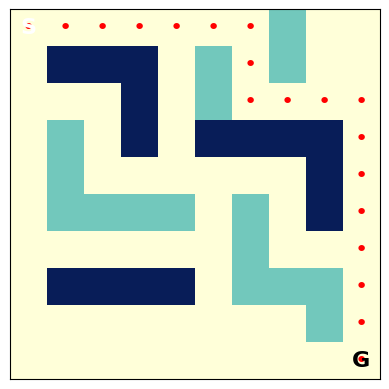

In [1]:
import heapq
import matplotlib.pyplot as plt
import numpy as np

# Constants
NORMAL = 1
HIGH_COST = 5
OBSTACLE = float('inf')

def get_neighbors(pos, grid):
    directions = [(-1,0), (1,0), (0,-1), (0,1)]  # up, down, left, right
    neighbors = []
    for dr, dc in directions:
        nr, nc = pos[0] + dr, pos[1] + dc
        if 0 <= nr < len(grid) and 0 <= nc < len(grid[0]) and grid[nr][nc] != OBSTACLE:
            neighbors.append((nr, nc))
    return neighbors

def reconstruct_path(came_from, start, goal):
    path = []
    current = goal
    while current != start:
        if current not in came_from:
            return []  # No path found
        path.append(current)
        current = came_from[current]
    path.append(start)
    path.reverse()
    return path

def ucs(grid, start, goal):
    frontier = [(0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        current_cost, current = heapq.heappop(frontier)

        if current == goal:
            break

        for neighbor in get_neighbors(current, grid):
            new_cost = cost_so_far[current] + grid[neighbor[0]][neighbor[1]]
            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                heapq.heappush(frontier, (new_cost, neighbor))
                came_from[neighbor] = current

    return reconstruct_path(came_from, start, goal)

def draw_grid(grid, path=None, start=None, goal=None):
    cmap = plt.cm.get_cmap("YlGnBu", 6)
    data = np.array(grid)
    data[data == OBSTACLE] = 10
    fig, ax = plt.subplots()
    ax.imshow(data, cmap=cmap, origin="upper")

    if path:
        for r, c in path:
            ax.text(c, r, '•', va='center', ha='center', color='red', fontsize=16)

    if start:
        ax.text(start[1], start[0], 'S', va='center', ha='center', color='white', fontsize=16, fontweight='bold')
    if goal:
        ax.text(goal[1], goal[0], 'G', va='center', ha='center', color='black', fontsize=16, fontweight='bold')

    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

# Grid Example
grid = [
    [1, 1, 1, 1, 1, 1, 1, HIGH_COST, 1, 1],
    [1, OBSTACLE, OBSTACLE, OBSTACLE, 1, HIGH_COST, 1, HIGH_COST, 1, 1],
    [1, 1, 1, OBSTACLE, 1, HIGH_COST, 1, 1, 1, 1],
    [1, HIGH_COST, 1, OBSTACLE, 1, OBSTACLE, OBSTACLE, OBSTACLE, OBSTACLE, 1],
    [1, HIGH_COST, 1, 1, 1, 1, 1, 1, OBSTACLE, 1],
    [1, HIGH_COST, HIGH_COST, HIGH_COST, HIGH_COST, 1, HIGH_COST, 1, OBSTACLE, 1],
    [1, 1, 1, 1, 1, 1, HIGH_COST, 1, 1, 1],
    [1, OBSTACLE, OBSTACLE, OBSTACLE, OBSTACLE, 1, HIGH_COST, HIGH_COST, HIGH_COST, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, HIGH_COST, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
]

start = (0, 0)
goal = (9, 9)

path = ucs(grid, start, goal)
print("UCS Path Length:", len(path))
draw_grid(grid, path, start, goal)


#  **Uniform Cost Search (UCS)**

A* Path Length: 19


<ipython-input-2-b9a77c42bae8>:56: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("YlGnBu", 6)


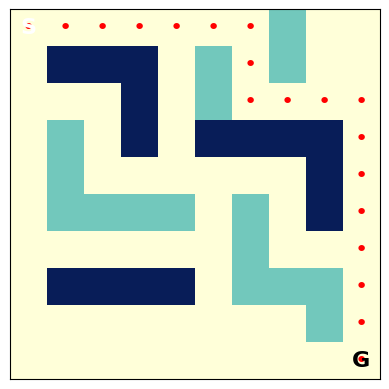

In [2]:
import heapq
import matplotlib.pyplot as plt
import numpy as np

# Constants
NORMAL = 1
HIGH_COST = 5
OBSTACLE = float('inf')

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])  # Manhattan distance

def get_neighbors(pos, grid):
    directions = [(-1,0), (1,0), (0,-1), (0,1)]  # up, down, left, right
    neighbors = []
    for dr, dc in directions:
        nr, nc = pos[0] + dr, pos[1] + dc
        if 0 <= nr < len(grid) and 0 <= nc < len(grid[0]) and grid[nr][nc] != OBSTACLE:
            neighbors.append((nr, nc))
    return neighbors

def reconstruct_path(came_from, start, goal):
    path = []
    current = goal
    while current != start:
        if current not in came_from:
            return []  # No path
        path.append(current)
        current = came_from[current]
    path.append(start)
    path.reverse()
    return path

def astar(grid, start, goal):
    frontier = [(0 + heuristic(start, goal), start)]
    came_from = {start: None}
    cost_so_far = {start: 0}

    while frontier:
        _, current = heapq.heappop(frontier)

        if current == goal:
            break

        for neighbor in get_neighbors(current, grid):
            new_cost = cost_so_far[current] + grid[neighbor[0]][neighbor[1]]
            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                priority = new_cost + heuristic(neighbor, goal)
                heapq.heappush(frontier, (priority, neighbor))
                came_from[neighbor] = current

    return reconstruct_path(came_from, start, goal)

def draw_grid(grid, path=None, start=None, goal=None):
    cmap = plt.cm.get_cmap("YlGnBu", 6)
    data = np.array(grid)
    data[data == OBSTACLE] = 10
    fig, ax = plt.subplots()
    ax.imshow(data, cmap=cmap, origin="upper")

    if path:
        for r, c in path:
            ax.text(c, r, '•', va='center', ha='center', color='red', fontsize=16)

    if start:
        ax.text(start[1], start[0], 'S', va='center', ha='center', color='white', fontsize=16, fontweight='bold')
    if goal:
        ax.text(goal[1], goal[0], 'G', va='center', ha='center', color='black', fontsize=16, fontweight='bold')

    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

# Grid Example
grid = [
    [1, 1, 1, 1, 1, 1, 1, HIGH_COST, 1, 1],
    [1, OBSTACLE, OBSTACLE, OBSTACLE, 1, HIGH_COST, 1, HIGH_COST, 1, 1],
    [1, 1, 1, OBSTACLE, 1, HIGH_COST, 1, 1, 1, 1],
    [1, HIGH_COST, 1, OBSTACLE, 1, OBSTACLE, OBSTACLE, OBSTACLE, OBSTACLE, 1],
    [1, HIGH_COST, 1, 1, 1, 1, 1, 1, OBSTACLE, 1],
    [1, HIGH_COST, HIGH_COST, HIGH_COST, HIGH_COST, 1, HIGH_COST, 1, OBSTACLE, 1],
    [1, 1, 1, 1, 1, 1, HIGH_COST, 1, 1, 1],
    [1, OBSTACLE, OBSTACLE, OBSTACLE, OBSTACLE, 1, HIGH_COST, HIGH_COST, HIGH_COST, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, HIGH_COST, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
]

start = (0, 0)
goal = (9, 9)

path = astar(grid, start, goal)
print("A* Path Length:", len(path))
draw_grid(grid, path, start, goal)
